<a href="https://colab.research.google.com/github/NoelVar/Ant_Colony_Optimization/blob/main/ANT_COLONY_VIDEO_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import random
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

In [ ]:
class ACO:
  def __init__(self):
    '''
    ------------------------------
    Initialisation function:

    Parameters:
      - Self

    Contains:
      - distances = weights of edges in graph
      - k = number of ants
      - tau = initial pheromone matrix
      - theta = heuristic matrix
      - alpha = pheromone importance value
      - beta = distance importance value
      - vertices = number of vertices in graph
      - iterations = number of iterations

    Purpose:
      - Initialise ACO algorithm parameters
      - run ACO algorithm
    ------------------------------
    '''
    # Multi-dimensional scaling
    #    - maps to lower dimention, while preserving as many pairwise distances
    self.mds = MDS(n_components=2, dissimilarity='precomputed')

    # self.distances = np.array([
    #     [0, 11.46, 70.45, 36.24, 68.15],
    #     [11.46, 0, 18.87, 72.37, 12.04],
    #     [70.45, 18.87, 0, 24.78, 19.31],
    #     [36.24, 72.37, 24.78, 0, 88.22],
    #     [68.15, 12.04, 19.32, 80.22, 0],
    # ])

    # Random symmetric matrix generation, with diagonal 0s
    self.distances = 100 * np.random.random((5,5))
    self.distances = (self.distances + self.distances.T) / 2
    np.fill_diagonal(self.distances, 0)
    print('-------------------------------------------------------------', '\n')
    print(self.distances, '\n')
    print('-------------------------------------------------------------', '\n')

    # Initialisation of variables
    d = self.distances

    self.k = 10
    self.tau = np.ones(d.shape)
    self.theta = self.heuristic()
    self.alpha = 1
    self.beta = 1
    self.evaporation = 0.5
    self.iterations = 20
    self.vertices = d.shape[0]

    self.best_tours = []
    self.best_costs = []
    self.best_tours_idxs = []
    self.coords = None

    # Run ACO algorithm
    self.run()




  # ----------------------------------------------------------------------------
  def heuristic(self):
    '''
    ------------------------------
    Heuristic function:

    Parameters:
      - Self

    Purpose:
      - Calculate heuristic matrix (Eta)

    Returns:
      - Heuristic matrix (Eta)
    ------------------------------
    '''
    d = self.distances
    theta = np.zeros(d.shape)

    # Applying heuristic on non 0 instances
    for i in range(d.shape[0]):
      for j in range(d.shape[1]):
        if self.distances[i][j] == 0:
          continue
        else:
          theta[i][j] = 1 / self.distances[i][j]
    return theta




  # ----------------------------------------------------------------------------
  def selection_probability(self, current, city, unvisited):
    '''
    ------------------------------
    Selection Probability function:

    Parameters:
      - Self
      - current = current city
      - city = city to visit
      - unvisited = list of unvisited cities

    Purpose:
      - Calculates the selection probability for the next city to visit

    Returns:
      - selection probability (numerator / denominator)
    ------------------------------
    '''
    numerator = (self.tau[current][city] ** self.alpha) * (self.theta[current][city] ** self.beta)
    denominator = 0
    for i in unvisited:
      denominator += (self.tau[current][i] ** self.alpha) * (self.theta[current][i] ** self.beta)

    return numerator / denominator




  # ----------------------------------------------------------------------------
  def pheromone_update(self, tours, costs):
    '''
    ------------------------------
    Pheromone Update function:

    Parameters:
      - Self
      - tours = list of tours
      - costs = list of costs

    Purpose:
      - Evaporate pheromone
      - Calculates value the pheromones should be updated by
      - Updates tau matrix

    Returns:
      - N/A
    ------------------------------
    '''
    self.tau *= (1 - self.evaporation)
    for tour, cost in zip(tours, costs):
      for i in range(len(tour) - 1):
        self.tau[tour[i]][tour[i + 1]] += 1 / cost




  # ----------------------------------------------------------------------------
  def calculate_cost(self, tour):
    '''
    ------------------------------
    Cost calculation function:

    Parameters:
      - Self
      - tours = single tour

    Purpose:
      - calculates distance between cities in tour

    Returns:
      - returns the total cost of the tour
    ------------------------------
    '''
    cost = 0
    for i in range(len(tour) - 1):
      cost += self.distances[tour[i]][tour[i + 1]]
    return cost




  # ----------------------------------------------------------------------------
  def visualise(self, best_tour_indexes):
    '''
    ------------------------------
    Visualiser function:

    Parameters:
      - Self
      - best_tour_indexes = the collection of all the best tour idxs

    Purpose:
      - Create the plot of the ACO algorithm
      - Show the best tour and the tours taken during the iterations
      - Show the convergence of the cost

    Returns:
      - A visualisation (plot) of the algorithm
    ------------------------------
    '''
    # Creating coordinates from distances using MDS
    self.coords = self.mds.fit_transform(self.distances)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
    axes[0].scatter(self.coords[:, 0], self.coords[:, 1], color='red')

    # All tours highlighted with 0.2 opacity black line
    for tour in self.best_tours_idxs:
      for i in range(len(tour)-1):
        axes[0].plot(
          [self.coords[tour[i]][0], self.coords[tour[i+1]][0]],
          [self.coords[tour[i]][1], self.coords[tour[i+1]][1]],
          color='black',
          alpha=0.2
        )

    # best tour highlighted with red line
    for i in range(len(best_tour_indexes)-1):
      axes[0].plot(
        [self.coords[best_tour_indexes[i]][0], self.coords[best_tour_indexes[i+1]][0]],
        [self.coords[best_tour_indexes[i]][1], self.coords[best_tour_indexes[i+1]][1]],
        color='red'
      )

    # Labels
    for idx, (x, y) in enumerate(self.coords):
      axes[0].annotate(str(idx + 1), (x, y), textcoords='offset points', xytext=(4, 4), fontsize=11)
    axes[0].set_title("Visualisation")
    axes[0].set_xlabel("X axis")
    axes[0].set_ylabel("Y axis")

    axes[1].plot(self.best_costs)
    axes[1].set_title("Cost Convergence")
    axes[1].set_xlabel("Iterations")
    axes[1].set_ylabel("Cost")
    fig.tight_layout()
    plt.show()




  # ----------------------------------------------------------------------------
  def run(self):
    '''
    ------------------------------
    Run function:

    Parameters:
      - Self

    Purpose:
      - The actual ACO algorithm itself
      - Runs the algorithm for the specified number of iterations
      - For each ant the ACO algorithm finds the cost of their tour
      - The best tour of the iteration is selected
      - At the end of the iteration the pheromone is updated
      - And the best tour is printed

    Returns:
      - N/A (prints the best tours in each iteration)
    ------------------------------
    '''
    for i in range(self.iterations):
      tours = []
      costs = []

      for ant in range(self.k):
        current = random.randint(0,  self.vertices - 1)
        visited = [current]

        while len(visited) < self.vertices:
          unvisited = []
          probabilities = []

          for city in range(self.vertices):
            if city not in visited:
              unvisited.append(city)

          for city in unvisited:
            probabilities.append(self.selection_probability(current, city, unvisited))

          current = np.random.choice(unvisited, p=probabilities)
          visited.append(current)

        visited.append(visited[0])
        tours.append(visited)
        costs.append(self.calculate_cost(visited))

      self.pheromone_update(tours, costs)

      best_cost_idx = costs.index(min(costs))
      best_cost = costs[best_cost_idx]
      best_tour = [int(c)+1 for c in tours[costs.index(min(costs))]]
      best_tour_indexes = [int(c) for c in tours[costs.index(min(costs))]]

      self.best_tours.append(best_tour)
      self.best_costs.append(best_cost)
      self.best_tours_idxs.append(best_tour_indexes)
      # print(f"Iteration {i} - Best tour cost: {best_cost:.2f} - Tour: {best_tour}")

    print('-------------------------------------------------------------', '\n')
    print(f"Best tour cost: {best_cost:.2f} - Tour: {best_tour}")
    print('-------------------------------------------------------------', '\n')
    best_idx = self.best_tours_idxs[self.best_costs.index(min(self.best_costs))]
    self.visualise(best_idx)


------------------------------------------------------------- 

[[ 0.         44.12447479 52.2601099  72.42807192 56.04520793]
 [44.12447479  0.         36.66358646 24.39479026 67.22142578]
 [52.2601099  36.66358646  0.         49.88864923 52.97301735]
 [72.42807192 24.39479026 49.88864923  0.         49.57023263]
 [56.04520793 67.22142578 52.97301735 49.57023263  0.        ]] 

------------------------------------------------------------- 

------------------------------------------------------------- 

Best tour cost: 218.93 - Tour: [4, 2, 3, 1, 5, 4]
------------------------------------------------------------- 



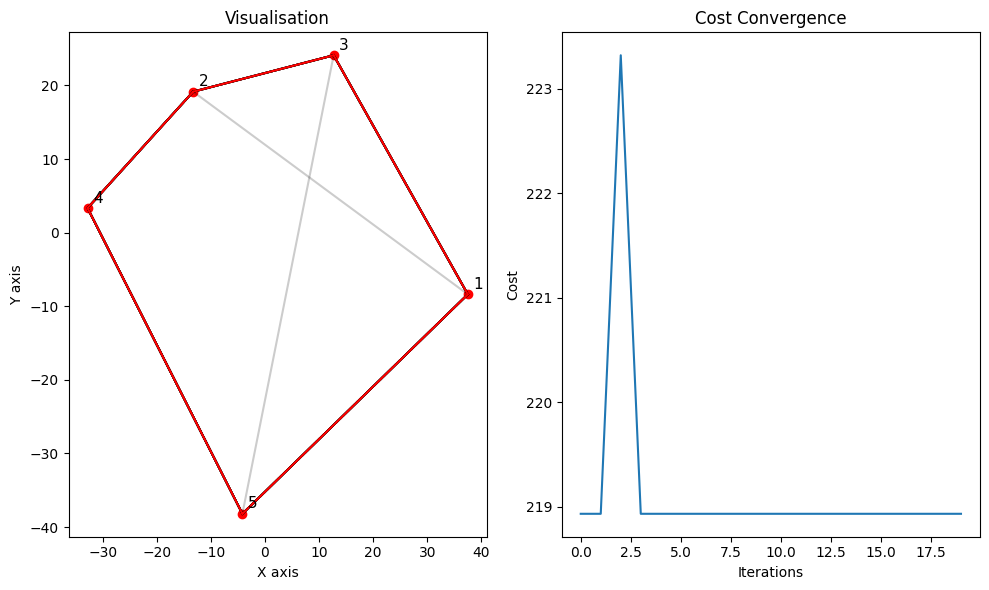

In [ ]:
ACO()